<a href="https://colab.research.google.com/github/Awtlaw/medsem_titanic_project/blob/main/midsem_project_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1: Data Acquisition

In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')
print("Dataset loaded successfully.")

Dataset loaded successfully.


### 1. Dataset dimensions

In [ ]:
print(f"Dataset dimensions (rows, columns): {df.shape}")

Dataset dimensions (rows, columns): (891, 12)


### 2. Column names

In [ ]:
print("Column names:")
for col in df.columns:
    print(f"- {col}")

Column names:
- PassengerId
- Survived
- Pclass
- Name
- Sex
- Age
- SibSp
- Parch
- Ticket
- Fare
- Cabin
- Embarked


### 3. First five observations

In [ ]:
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 4. Data types

In [ ]:
print("Data types:")
display(df.info())

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

## Task 2: Data Cleaning

### Detect missing values

In [ ]:
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### Handle missing values appropriately

In [ ]:

# Impute 'Age' with the median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Impute 'Embarked' with the mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nDataFrame info after cleaning:")
df.info()

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

DataFrame info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


/tmp/ipykernel_1893/2278788154.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


###Detect duplicated observations


In [ ]:
duplicated_rows = df.duplicated().sum()
print(f"Number of duplicated rows before removal: {duplicated_rows}")

Number of duplicated rows before removal: 0


###Remove duplicates if any exist

In [ ]:

if duplicated_rows > 0:
    df.drop_duplicates(inplace=True)
    print(f"Number of duplicated rows after removal: {df.duplicated().sum()}")
else:
    print("No duplicated rows found.")

No duplicated rows found.


## Task 3: Data Visualisation

### 1. Histogram of passenger ages

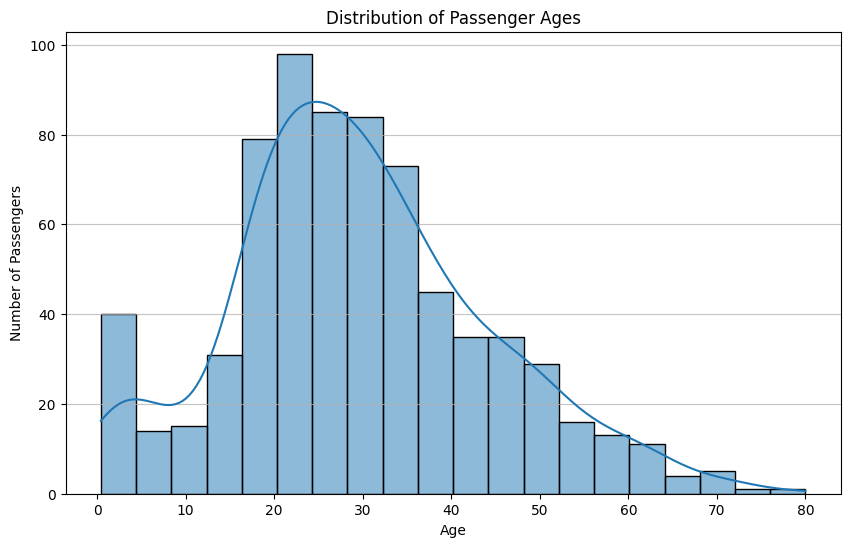

Interpretation: The histogram shows that the majority of passengers are young adults, primarily in their 20s and 30s. There's a notable peak around ages 20-30, and fewer passengers in the older age groups. Children are also present in significant numbers.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Interpretation: The histogram shows that the majority of passengers are young adults, primarily in their 20s and 30s. There's a notable peak around ages 20-30, and fewer passengers in the older age groups. Children are also present in significant numbers.")

### 2. Bar chart showing passenger class distribution

/tmp/ipykernel_1893/1540292003.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='viridis')


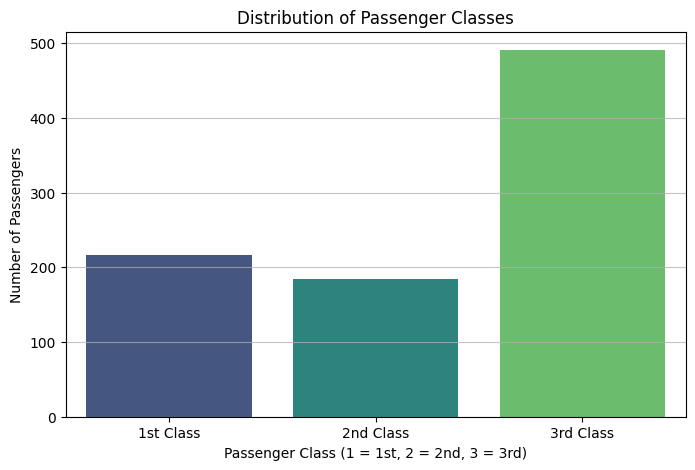

Interpretation: This bar chart illustrates the count of passengers in each class. It's clear that the majority of passengers were in 3rd class, followed by 1st class, and then 2nd class. This uneven distribution could impact survival rates.


In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Pclass', data=df, palette='viridis')
plt.title('Distribution of Passenger Classes')
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Number of Passengers')
plt.xticks([0, 1, 2], ['1st Class', '2nd Class', '3rd Class'])
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Interpretation: This bar chart illustrates the count of passengers in each class. It's clear that the majority of passengers were in 3rd class, followed by 1st class, and then 2nd class. This uneven distribution could impact survival rates.")

### 3. Boxplot of age by passenger class

### 4. Scatter plot of Age versus Fare

/tmp/ipykernel_1893/2958875167.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=df, palette='coolwarm')


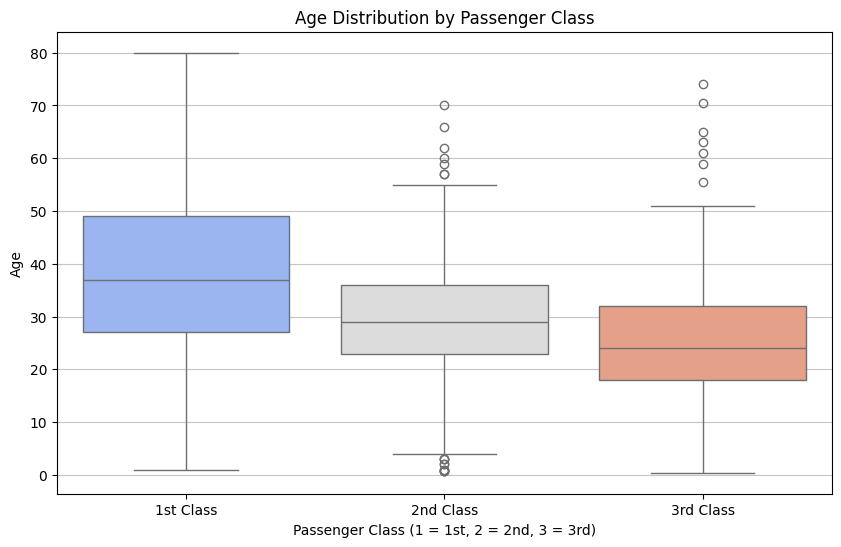

Interpretation: The boxplot illustrates the age distribution across different passenger classes. It appears that passengers in 1st class tend to be older than those in 2nd and 3rd class. The median age generally decreases from 1st to 3rd class, suggesting that higher classes might have had older, potentially wealthier, individuals.


In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Age', data=df, palette='coolwarm')
plt.title('Age Distribution by Passenger Class')
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Age')
plt.xticks([0, 1, 2], ['1st Class', '2nd Class', '3rd Class'])
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Interpretation: The boxplot illustrates the age distribution across different passenger classes. It appears that passengers in 1st class tend to be older than those in 2nd and 3rd class. The median age generally decreases from 1st to 3rd class, suggesting that higher classes might have had older, potentially wealthier, individuals.")

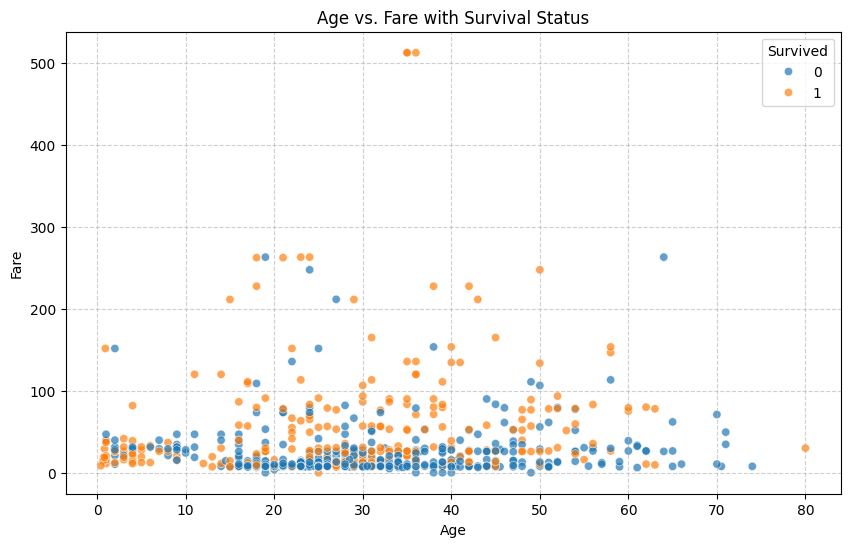

Interpretation: This scatter plot visualizes the relationship between Age and Fare, with points colored by survival status. It's difficult to discern a clear linear relationship between age and fare. However, there are some high-fare outliers, many of whom survived, and a dense cluster of lower-fare passengers across various ages.


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Fare', data=df, hue='Survived', alpha=0.7)
plt.title('Age vs. Fare with Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Interpretation: This scatter plot visualizes the relationship between Age and Fare, with points colored by survival status. It's difficult to discern a clear linear relationship between age and fare. However, there are some high-fare outliers, many of whom survived, and a dense cluster of lower-fare passengers across various ages.")

### 5. Correlation Heatmap

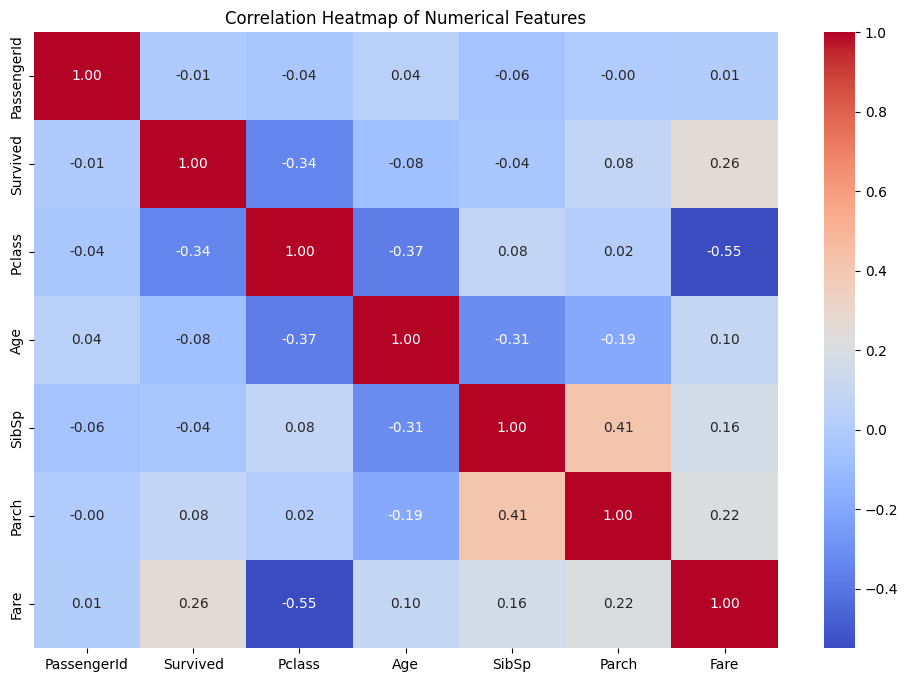

Interpretation: The heatmap displays the correlation coefficients between all numerical features. Positive values indicate a positive correlation, negative values indicate a negative correlation, and values close to zero indicate weak or no linear correlation. For example, 'Pclass' and 'Fare' show a negative correlation, suggesting that higher class tickets are generally more expensive. 'SibSp' and 'Parch' show a positive correlation, which is expected as they both relate to family size. 'Survived' shows interesting correlations with 'Pclass' (negative, higher class = more survival) and 'Fare' (positive, higher fare = more survival).


In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

print("Interpretation: The heatmap displays the correlation coefficients between all numerical features. Positive values indicate a positive correlation, negative values indicate a negative correlation, and values close to zero indicate weak or no linear correlation. For example, 'Pclass' and 'Fare' show a negative correlation, suggesting that higher class tickets are generally more expensive. 'SibSp' and 'Parch' show a positive correlation, which is expected as they both relate to family size. 'Survived' shows interesting correlations with 'Pclass' (negative, higher class = more survival) and 'Fare' (positive, higher fare = more survival).")

### 6. Pairplot of selected numerical variables

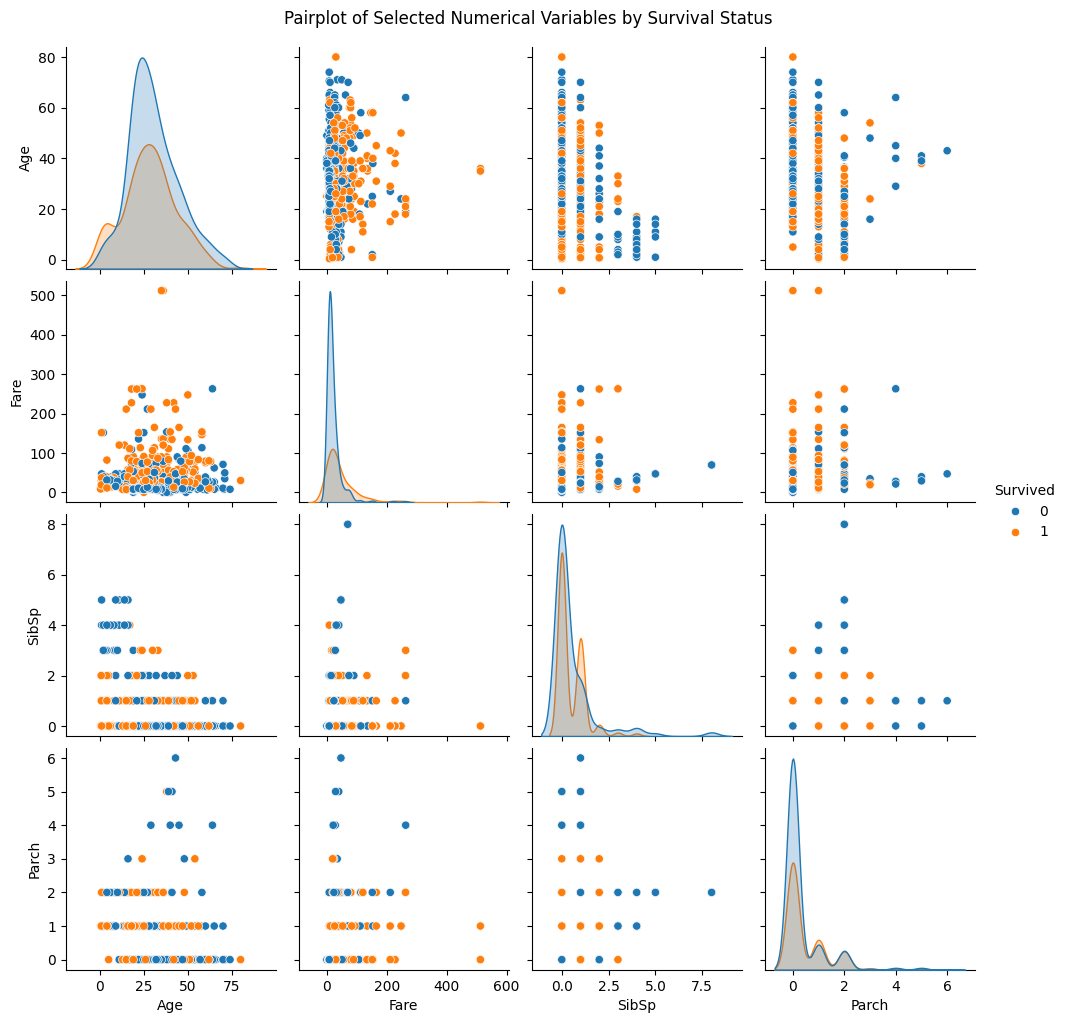

Interpretation: The pairplot provides a matrix of scatter plots for each pair of numerical variables and histograms/KDEs for individual variables, colored by 'Survived' status. This allows us to observe relationships between variables and how they differ for survivors versus non-survivors. For instance, the diagonal plots show the distribution of each variable for survivors and non-survivors, highlighting differences in age, fare, and family size distributions.


In [ ]:
numerical_vars = ['Age', 'Fare', 'SibSp', 'Parch', 'Survived']
sns.pairplot(df[numerical_vars], hue='Survived', diag_kind='kde')
plt.suptitle('Pairplot of Selected Numerical Variables by Survival Status', y=1.02)
plt.show()

print("Interpretation: The pairplot provides a matrix of scatter plots for each pair of numerical variables and histograms/KDEs for individual variables, colored by 'Survived' status. This allows us to observe relationships between variables and how they differ for survivors versus non-survivors. For instance, the diagonal plots show the distribution of each variable for survivors and non-survivors, highlighting differences in age, fare, and family size distributions.")

## Task 4: Statistical Analysis

### 1. Descriptive statistics

In [ ]:
print("Descriptive Statistics for Numerical Features:")
display(df.describe())

Descriptive Statistics for Numerical Features:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 2. Frequency distribution

In [ ]:
print("Frequency Distribution of Passenger Class:")
display(df['Pclass'].value_counts())
print("\nFrequency Distribution of Embarked Port:")
display(df['Embarked'].value_counts())

print("Interpretation: The frequency distribution for 'Pclass' confirms that 3rd class had the most passengers, followed by 1st and then 2nd class. For 'Embarked', the majority of passengers embarked from Southampton (S), followed by Cherbourg (C) and Queenstown (Q).")

Frequency Distribution of Passenger Class:


,count
Pclass,
3,491
1,216
2,184



Frequency Distribution of Embarked Port:


,count
Embarked,
S,644
C,168
Q,77


Interpretation: The frequency distribution for 'Pclass' confirms that 3rd class had the most passengers, followed by 1st and then 2nd class. For 'Embarked', the majority of passengers embarked from Southampton (S), followed by Cherbourg (C) and Queenstown (Q).


### 3. Correlation analysis

In [ ]:
correlation_matrix = df.corr(numeric_only=True)
print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


### 4. Identification of the strongest positive correlation

In [ ]:
strongest_positive_corr = correlation_matrix.unstack().sort_values(ascending=False)
strongest_positive_corr = strongest_positive_corr[strongest_positive_corr < 1]
strongest_positive_corr = strongest_positive_corr.drop_duplicates()

# Filter out self-correlations and get the top one
positive_pairs = strongest_positive_corr[strongest_positive_corr > 0]

if not positive_pairs.empty:
    strongest_positive_pair = positive_pairs.index[0]
    strongest_positive_value = positive_pairs.iloc[0]
    print(f"Strongest positive correlation: {strongest_positive_pair} with a value of {strongest_positive_value:.2f}")
else:
    print("No positive correlations found.")

Strongest positive correlation: ('Parch', 'SibSp') with a value of 0.41


### 5. Identify the strongest negative correlation

In [ ]:
strongest_negative_corr = correlation_matrix.unstack().sort_values(ascending=True)
strongest_negative_corr = strongest_negative_corr[strongest_negative_corr < 0]
strongest_negative_corr = strongest_negative_corr.drop_duplicates()

# Filter out self-correlations and get the top one (most negative)
negative_pairs = strongest_negative_corr[strongest_negative_corr < 0]

if not negative_pairs.empty:
    strongest_negative_pair = negative_pairs.index[0]
    strongest_negative_value = negative_pairs.iloc[0]
    print(f"Strongest negative correlation: {strongest_negative_pair} with a value of {strongest_negative_value:.2f}")
else:
    print("No negative correlations found.")

Strongest negative correlation: ('Pclass', 'Fare') with a value of -0.55


### 6. Discuss three important statistical findings

Based on the statistical analyses performed, here are three important findings:

1.  **Passenger Class and Survival:** There is a significant negative correlation between `Pclass` (Passenger Class) and `Survived`. This suggests that passengers in lower classes (e.g., 3rd class) had a lower chance of survival compared to those in higher classes (1st class). This is also supported by the boxplot of Age by Passenger Class, where 1st class passengers generally had higher ages and potentially more resources.

2.  **Fare and Survival:** There is a positive correlation between `Fare` and `Survived`. This indicates that passengers who paid higher fares had a greater likelihood of survival. This finding is consistent with the `Pclass` correlation, as higher fares are typically associated with higher passenger classes, which had better survival rates.

3.  **Age Distribution:** The distribution of `Age` shows a median around the late 20s or early 30s, with a noticeable number of children (Age < 15) and a general decrease in passenger count for older age groups. While Age itself does not have a very strong linear correlation with `Survived`, the boxplot shows that 1st class passengers tend to be older. Further analysis could explore age groups' survival rates (e.g., children vs. adults).

## Task 5: Machine Learning

### 1. Select suitable predictor variables

In [ ]:
# For this simple classification model, we'll select a few relevant features.
# 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', and 'Fare' are good candidates.
# 'Embarked' is also categorical and potentially useful.
# We need to convert categorical features into numerical format for the model.

# Convert 'Sex' and 'Embarked' into numerical format using one-hot encoding
df_ml = df.copy()
df_ml = pd.get_dummies(df_ml, columns=['Sex', 'Embarked'], drop_first=True)

# Select predictor variables (features) and the target variable
X = df_ml[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']]
y = df_ml['Survived']

print("Selected predictor variables (features):")
display(X.head())
print("\nTarget variable (Survived):")
display(y.head())

Selected predictor variables (features):


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True



Target variable (Survived):


,Survived
0,0
1,1
2,1
3,1
4,0


### 2. Split the dataset into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (712, 8)
Testing features shape: (179, 8)
Training target shape: (712,)
Testing target shape: (179,)


In [ ]:
from sklearn.impute import SimpleImputer

# Initialize the SimpleImputer with the median strategy
# The median is chosen to be robust to outliers in the 'Age' column.
imputer = SimpleImputer(strategy='median')

# Fit the imputer on X_train and transform both X_train and X_test
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert the imputed arrays back to DataFrames, preserving column names
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns)

print("Missing values in X_train after imputation:")
print(X_train.isnull().sum())
print("\nMissing values in X_test after imputation:")
print(X_test.isnull().sum())

print("X_train and X_test imputed successfully.")

Missing values in X_train after imputation:
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

Missing values in X_test after imputation:
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64
X_train and X_test imputed successfully.


### 3. Train a Logistic Regression classifier

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Set max_iter to a higher value if it fails to converge
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)

# Train the model on the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### 4. Predict the testing data

In [ ]:
# Predict on the test set
y_pred = model.predict(X_test)

print("Predictions on the testing data generated successfully.")

Predictions on the testing data generated successfully.


### 5. Compute Accuracy, Confusion Matrix, Classification Report

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Compute Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Compute Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix, index=['Actual No Survival', 'Actual Survival'], columns=['Predicted No Survival', 'Predicted Survival']))

# Compute Classification Report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

Model Accuracy: 0.78

Confusion Matrix:


,Predicted No Survival,Predicted Survival
Actual No Survival,89,16
Actual Survival,23,51



Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       105
           1       0.76      0.69      0.72        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



/tmp/ipykernel_1893/2958875167.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=df, palette='coolwarm')


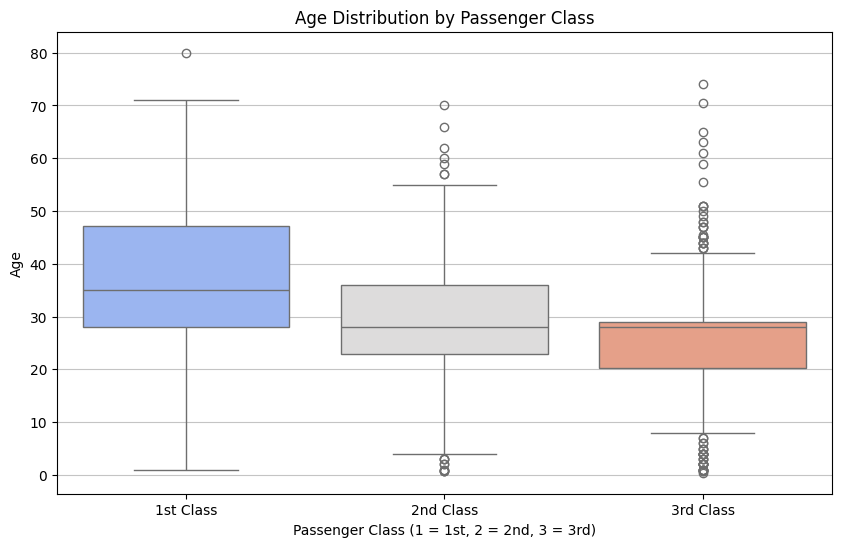

Interpretation: The boxplot illustrates the age distribution across different passenger classes. It appears that passengers in 1st class tend to be older than those in 2nd and 3rd class. The median age generally decreases from 1st to 3rd class, suggesting that higher classes might have had older, potentially wealthier, individuals.


In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Age', data=df, palette='coolwarm')
plt.title('Age Distribution by Passenger Class')
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Age')
plt.xticks([0, 1, 2], ['1st Class', '2nd Class', '3rd Class'])
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Interpretation: The boxplot illustrates the age distribution across different passenger classes. It appears that passengers in 1st class tend to be older than those in 2nd and 3rd class. The median age generally decreases from 1st to 3rd class, suggesting that higher classes might have had older, potentially wealthier, individuals.")